In [42]:
!git clone https://github.com/hananbahtiti/School.git

fatal: destination path 'School' already exists and is not an empty directory.


In [43]:
import pandas as pd
from sklearn import preprocessing
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Data Dictionary / Column Descriptions

| Column Name                          | Description                                                                                          |
|------------------------------------|----------------------------------------------------------------------------------------------------|
| **DBN**                            | District Borough Number — unique identifier assigned to each school within the NYC Department of Education system. |
| **School Name**                    | The official full name of the school.                                                              |
| **School Type**                    | Classification of the school, such as Elementary, Middle, or High School.                           |
| **Parent Response Rate** (%)      | Percentage of parents who responded to the school survey, indicating parent engagement.            |
| **Teacher Response Rate** (%)     | Percentage of teachers who participated in the survey, reflecting staff involvement.               |
| **Student Response Rate** (%)     | Percentage of students who completed the survey, measuring student participation.                   |
| **Total Safety and Respect Score**| Aggregate score assessing perceptions of safety and respect within the school environment.         |
| **Total Communication Score**     | Score evaluating the effectiveness of communication between the school, families, and staff.       |
| **Total Engagement Score**        | Score measuring the level of engagement among students, families, and staff.                        |
| **Total Academic Expectations Score** | Score representing the academic expectations and rigor promoted by the school.                  |


In [226]:
# Load the dataset from the specified CSV file path into a DataFrame
file = '/content/School/General_Education_School.csv'
df = pd.read_csv(file)

# Display a concise summary of the DataFrame including column names, data types, and non-null counts
print(f"{df.info()}")

# Display the first five rows of the dataset for a quick preview of the data
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   DBN                                1671 non-null   object
 1   School Name                        1671 non-null   object
 2   School Type                        1670 non-null   object
 3   Parent Response Rate               1671 non-null   object
 4   Teacher Response Rate              1671 non-null   object
 5   Student Response Rate              996 non-null    object
 6   Total Safety and Respect Score     1671 non-null   object
 7   Total Communication Score          1671 non-null   object
 8   Total Engagement Score             1671 non-null   object
 9   Total Academic Expectations Score  1671 non-null   object
dtypes: object(10)
memory usage: 130.7+ KB
None


,DBN,School Name,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
0,dbn,locationname,NaN,rr_p,rr_t,rr_s,saf_tot_12,com_tot_12,eng_tot_12,aca_tot_12
1,01M015,P.S. 015 Roberto Clemente,Elementary School,61%,92%,NaN,8.4,8.2,8.3,8.2
2,01M019,P.S. 019 Asher Levy,Elementary School,92%,94%,NaN,8.4,8,8,8.2
3,01M020,P.S. 020 Anna Silver,Elementary School,88%,73%,NaN,8.5,7.8,8.2,8.2
4,01M034,P.S. 034 Franklin D. Roosevelt,Elementary/Middle School,39%,58%,96%,7.3,6.9,7.3,7.7


#**1. Data Cleaning**

In [227]:
# Create a copy of the original DataFrame to avoid modifying it directly
df = df.copy()

# Remove the first row based on its integer position using .iloc
# This is useful when the first row contains metadata or is not part of the actual data
df = df.iloc[1:].copy()

# Display the structure of the DataFrame after removing the first row
df.info()

# Display the first five rows of the updated DataFrame to verify the changes
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670 entries, 1 to 1670
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   DBN                                1670 non-null   object
 1   School Name                        1670 non-null   object
 2   School Type                        1670 non-null   object
 3   Parent Response Rate               1670 non-null   object
 4   Teacher Response Rate              1670 non-null   object
 5   Student Response Rate              995 non-null    object
 6   Total Safety and Respect Score     1670 non-null   object
 7   Total Communication Score          1670 non-null   object
 8   Total Engagement Score             1670 non-null   object
 9   Total Academic Expectations Score  1670 non-null   object
dtypes: object(10)
memory usage: 130.6+ KB


,DBN,School Name,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
1,01M015,P.S. 015 Roberto Clemente,Elementary School,61%,92%,NaN,8.4,8.2,8.3,8.2
2,01M019,P.S. 019 Asher Levy,Elementary School,92%,94%,NaN,8.4,8,8,8.2
3,01M020,P.S. 020 Anna Silver,Elementary School,88%,73%,NaN,8.5,7.8,8.2,8.2
4,01M034,P.S. 034 Franklin D. Roosevelt,Elementary/Middle School,39%,58%,96%,7.3,6.9,7.3,7.7
5,01M063,P.S. 063 William Mckinley,Elementary School,58%,100%,NaN,8.5,7.4,7.6,7.8


In [228]:
# Convert selected survey score columns to float type for accurate numerical analysis
df[['Total Academic Expectations Score',
    'Total Engagement Score',
    'Total Communication Score',
    'Total Safety and Respect Score']] = df[[
        'Total Academic Expectations Score',
        'Total Engagement Score',
        'Total Communication Score',
        'Total Safety and Respect Score'
    ]].astype(float)

# Remove percentage signs and convert response rate columns to integers
# 'errors="coerce"' will convert any invalid entries to NaN
df[['Student Response Rate',
    'Teacher Response Rate',
    'Parent Response Rate']] = df[[
        'Student Response Rate',
        'Teacher Response Rate',
        'Parent Response Rate'
    ]].replace(r'%', '', regex=True).astype('Int64')  # Use nullable integer type


# Display a concise summary of the DataFrame including updated data types and null counts
print(f"{df.info()}")

# Display the first five rows to confirm the changes and inspect data quality
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670 entries, 1 to 1670
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DBN                                1670 non-null   object 
 1   School Name                        1670 non-null   object 
 2   School Type                        1670 non-null   object 
 3   Parent Response Rate               1670 non-null   Int64  
 4   Teacher Response Rate              1670 non-null   Int64  
 5   Student Response Rate              995 non-null    Int64  
 6   Total Safety and Respect Score     1670 non-null   float64
 7   Total Communication Score          1670 non-null   float64
 8   Total Engagement Score             1670 non-null   float64
 9   Total Academic Expectations Score  1670 non-null   float64
dtypes: Int64(3), float64(4), object(3)
memory usage: 135.5+ KB
None
      DBN                     School Name               

In [229]:
# Remove duplicate rows from the DataFrame to ensure data integrity
df = df.drop_duplicates()

# Display concise summary of the DataFrame including column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1667 entries, 1 to 1667
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DBN                                1667 non-null   object 
 1   School Name                        1667 non-null   object 
 2   School Type                        1667 non-null   object 
 3   Parent Response Rate               1667 non-null   Int64  
 4   Teacher Response Rate              1667 non-null   Int64  
 5   Student Response Rate              994 non-null    Int64  
 6   Total Safety and Respect Score     1667 non-null   float64
 7   Total Communication Score          1667 non-null   float64
 8   Total Engagement Score             1667 non-null   float64
 9   Total Academic Expectations Score  1667 non-null   float64
dtypes: Int64(3), float64(4), object(3)
memory usage: 148.1+ KB


In [230]:
# Remove the 'School Name' column from the DataFrame as it is no longer needed for analysis.
# The 'axis=1' parameter specifies that a column (not a row) is being dropped.
# 'inplace=True' ensures the change is applied directly to the original DataFrame without needing reassignment.
df.drop('School Name', axis=1, inplace=True)

# Display summary information about the DataFrame after removing the column,
# including the number of entries, column data types, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1667 entries, 1 to 1667
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DBN                                1667 non-null   object 
 1   School Type                        1667 non-null   object 
 2   Parent Response Rate               1667 non-null   Int64  
 3   Teacher Response Rate              1667 non-null   Int64  
 4   Student Response Rate              994 non-null    Int64  
 5   Total Safety and Respect Score     1667 non-null   float64
 6   Total Communication Score          1667 non-null   float64
 7   Total Engagement Score             1667 non-null   float64
 8   Total Academic Expectations Score  1667 non-null   float64
dtypes: Int64(3), float64(4), object(2)
memory usage: 135.1+ KB


<ipython-input-230-f5558f842298>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('School Name', axis=1, inplace=True)


In [231]:
# Calculate and display the percentage of missing (null) values for each column in the DataFrame
# This helps identify data quality issues and assess the need for cleaning or imputation
print(f"Counts of null values (as percentage of total rows): \n{df.isnull().sum() / len(df) * 100}")


Counts of null values (as percentage of total rows): 
DBN                                   0.000000
School Type                           0.000000
Parent Response Rate                  0.000000
Teacher Response Rate                 0.000000
Student Response Rate                40.371926
Total Safety and Respect Score        0.000000
Total Communication Score             0.000000
Total Engagement Score                0.000000
Total Academic Expectations Score     0.000000
dtype: float64


In [232]:
# Replace missing values in the 'Student Response Rate' column with 0
df['Student Response Rate'].fillna(0, inplace=True)

# Display a concise summary of the DataFrame, including column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1667 entries, 1 to 1667
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DBN                                1667 non-null   object 
 1   School Type                        1667 non-null   object 
 2   Parent Response Rate               1667 non-null   Int64  
 3   Teacher Response Rate              1667 non-null   Int64  
 4   Student Response Rate              1667 non-null   Int64  
 5   Total Safety and Respect Score     1667 non-null   float64
 6   Total Communication Score          1667 non-null   float64
 7   Total Engagement Score             1667 non-null   float64
 8   Total Academic Expectations Score  1667 non-null   float64
dtypes: Int64(3), float64(4), object(2)
memory usage: 135.1+ KB


<ipython-input-232-e27a217b332d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Student Response Rate'].fillna(0, inplace=True)
<ipython-input-232-e27a217b332d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Student Response Rate'].fillna(0, inplace=True)


#**2. Exploratory Data Analysis**

In [ ]:
# Iterate through all columns in the DataFrame
# For each column, print its name and display the frequency count of each unique value
# This is useful for understanding the distribution of categorical and discrete data
for col in df.columns:
    print(f'================= {col} =================')
    print(f'{df[col].value_counts()}')


================= DBN =================
DBN
84X730    1
01M015    1
01M019    1
84X482    1
84X461    1
         ..
01M134    1
01M110    1
01M064    1
01M063    1
01M034    1
Name: count, Length: 1667, dtype: int64
================= School Type =================
School Type
Elementary School                617
High School                      352
Middle School                    292
Elementary/Middle School         160
Middle/High School                87
Early Childhood School            81
Transfer High School              49
YABC                              22
Elementary/Middle/High School      7
Name: count, dtype: int64
================= Parent Response Rate =================
Parent Response Rate
100    45
58     35
73     32
45     30
63     29
       ..
10      3
1       3
4       3
3       3
8       2
Name: count, Length: 100, dtype: Int64
================= Teacher Response Rate =================
Teacher Response Rate
100    332
96      84
88      68
97      60
94      52
   

In [ ]:
# Display the number of unique values in each column of the DataFrame
# Useful for understanding the variability and cardinality of features
print(f"{df.nunique()}")


DBN                                  1667
School Type                             9
Parent Response Rate                  100
Teacher Response Rate                  83
Student Response Rate                  74
Total Safety and Respect Score         44
Total Communication Score              42
Total Engagement Score                 40
Total Academic Expectations Score      39
dtype: int64


In [ ]:
# Generate descriptive statistics for all numerical columns in the DataFrame
# Includes metrics such as count, mean, standard deviation, min, max, and quartiles
df.describe()


,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
count,1667.0,1667.0,1667.0,1667.000000,1667.000000,1667.000000,1667.000000
mean,56.335933,83.403119,50.405519,7.850330,7.299820,7.582244,7.879544
std,25.008905,17.426696,43.317526,0.745997,0.697943,0.662616,0.624073
min,1.0,0.0,0.0,4.700000,4.700000,4.800000,5.300000
25%,37.0,75.0,0.0,7.300000,6.800000,7.100000,7.500000
50%,57.0,88.0,71.0,7.900000,7.300000,7.600000,7.900000
75%,76.0,97.0,92.0,8.400000,7.800000,8.000000,8.300000
max,100.0,100.0,100.0,9.600000,9.200000,9.300000,9.500000


In [ ]:
# Initialize the LabelEncoder
label_encoder = preprocessing.LabelEncoder()

# Specify the categorical columns to encode
cols_to_encode = ['DBN', 'School Type']

# Apply LabelEncoder to each specified column to convert categorical values to numeric labels
for col in cols_to_encode:
    df[col] = label_encoder.fit_transform(df[col])

# Display the first few rows of the encoded DataFrame to verify the transformation
df.head()

,DBN,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
1,0,1,61,92,0,8.4,8.2,8.3,8.2
2,1,1,92,94,0,8.4,8.0,8.0,8.2
3,2,1,88,73,0,8.5,7.8,8.2,8.2
4,3,2,39,58,96,7.3,6.9,7.3,7.7
5,4,1,58,100,0,8.5,7.4,7.6,7.8


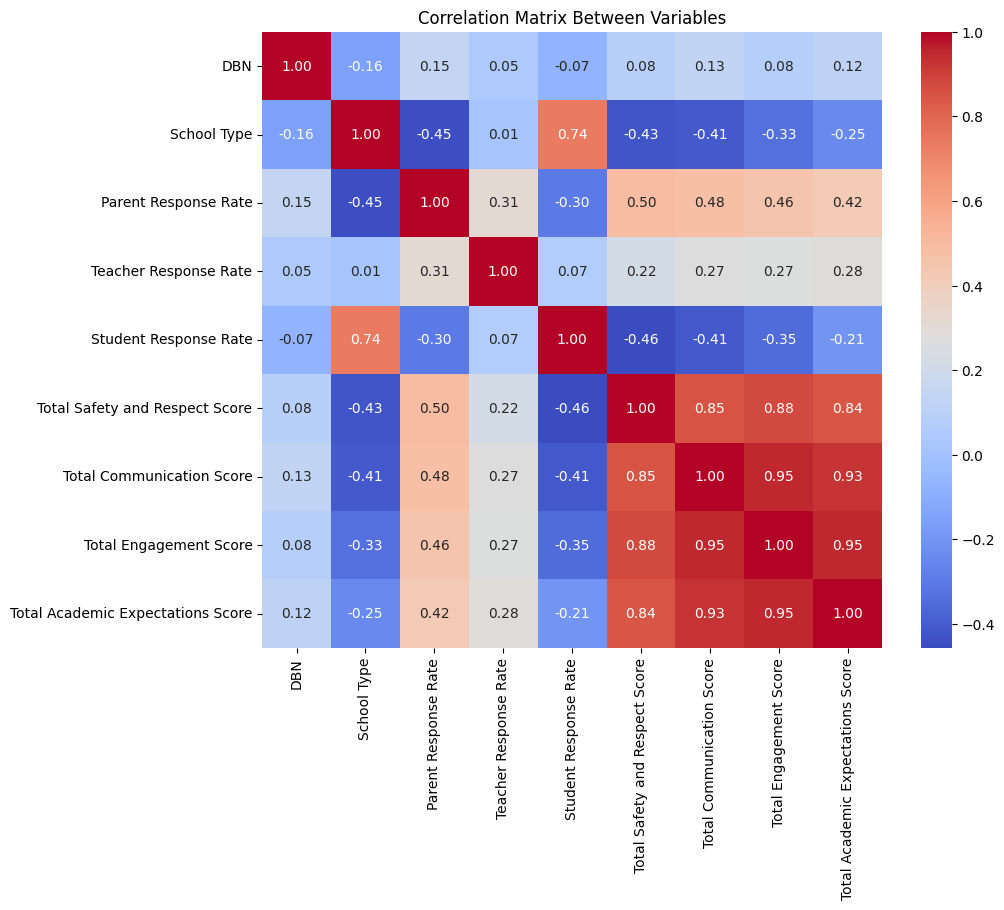

In [ ]:
# Set the size of the figure for better readability
plt.figure(figsize=(10, 8))

# Generate a heatmap to visualize the correlation matrix between variables
# 'annot=True' displays the correlation coefficients on the heatmap
# 'cmap="coolwarm"' sets the color scheme
# 'fmt=".2f"' formats the correlation values to two decimal places
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# Set the title of the heatmap
plt.title('Correlation Matrix Between Variables')

# Display the heatmap
plt.show()

#**3. Deep Dive**

In [ ]:
# Group the data by 'Parent Response Rate' and 'Total Communication Score' and count the number of occurrences
# This helps to analyze how frequently each combination appears
Parent = df.groupby(['School Type']).size()

# Sort the grouped data in descending order for better visualization
Parent_sorted = Parent.sort_values(ascending=False)

# Plotting the grouped and sorted data as a bar chart
plt.figure(figsize=(13, 9))
Parent_sorted.plot(kind='bar', linewidth=3)

# Set title and axis labels with proper formatting
plt.title('Distribution of School Type', fontsize=24)
plt.xlabel('School Type', fontsize=20)
plt.ylabel('Number of Occurrences', fontsize=20)
plt.xticks(rotation=45)

In [ ]:
# Calculate the percentage distribution of each category in the 'School Type' column
counts = df['School Type'].value_counts(normalize=True) * 100

# Set up the figure size
fig, ax = plt.subplots(figsize=(15, 15))

# Define custom colors using a colormap to ensure unique colors for each category
colors = plt.cm.tab20.colors[:len(counts)]

# Create the pie chart with percentage labels and custom font size
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,                      # We'll use a legend instead of direct labels
    autopct='%1.1f%%',                # Show percentage with one decimal
    startangle=90,                    # Start the pie from 90 degrees for balance
    colors=colors,
    textprops={'fontsize': 14}        # Font size for the percentage texts
)

# Set chart title with italic font style and larger font size
ax.set_title('Percentage Distribution of School Types', fontstyle='italic', fontsize=18)

# Add a legend to the side showing each school type and its corresponding color
ax.legend(
    wedges,
    counts.index,
    title="School Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),          # Position the legend outside the chart
    fontsize=12,
    title_fontsize=14
)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()
plt.show()

In [233]:
# Group by 'School Type' and calculate the mean for the selected columns
school_scores = df.groupby(['School Type'])[[
    'Parent Response Rate',
    'Teacher Response Rate',
    'Student Response Rate',
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]].mean().reset_index()

# Convert score columns to percentages (assuming scores are out of 10)
score_columns = [
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]

#school_scores[score_columns] = school_scores[score_columns] * 10

# Display the final DataFrame
school_scores

,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
0,Early Childhood School,76.481481,88.444444,0.0,8.637037,8.027160,8.162963,8.386420
1,Elementary School,68.526742,82.418152,4.294976,8.273906,7.645867,7.872609,8.051053
2,Elementary/Middle School,60.9375,82.51875,93.7625,7.661250,7.245625,7.536250,7.961250
3,Elementary/Middle/High School,54.714286,76.285714,91.571429,7.471429,6.857143,7.128571,7.514286
4,High School,35.09375,84.252841,77.494318,7.394886,6.848864,7.157102,7.530966
5,Middle School,58.681507,83.832192,90.287671,7.453082,7.065753,7.416781,7.804795
6,Middle/High School,40.218391,80.045977,83.965517,7.398851,6.847126,7.124138,7.514943
7,Transfer High School,35.653061,89.959184,68.102041,8.091837,7.238776,7.775510,8.044898
8,YABC,25.863636,80.545455,65.863636,8.377273,7.700000,8.159091,8.368182


In [234]:

freq = df['School Type'].value_counts()

# حساب الوزن العكسي (1 / التكرار)
weights = 1 / freq

# ربط الوزن بكل صف حسب نوع المدرسة
df['weight'] = df['School Type'].map(weights)

# الأعمدة الرقمية التي تريد حساب المتوسطات الموزونة لها
metrics = [
    'Parent Response Rate', 'Teacher Response Rate', 'Student Response Rate',
    'Total Safety and Respect Score', 'Total Communication Score',
    'Total Engagement Score', 'Total Academic Expectations Score'
]

# دالة لحساب المتوسط الموزون حسب الوزن داخل كل مجموعة
def weighted_avg(group, value_col):
    return (group[value_col] * group['weight']).sum() / group['weight'].sum()

# حساب المتوسطات الموزونة لكل عمود داخل كل school type
weighted_means = df.groupby('School Type').apply(
    lambda g: pd.Series({col: weighted_avg(g, col) for col in metrics})
)


weighted_means

<ipython-input-234-70e90adba5a1>:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = df.groupby('School Type').apply(


,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
School Type,,,,,,,
Early Childhood School,76.481481,88.444444,0.000000,8.637037,8.027160,8.162963,8.386420
Elementary School,68.526742,82.418152,4.294976,8.273906,7.645867,7.872609,8.051053
Elementary/Middle School,60.937500,82.518750,93.762500,7.661250,7.245625,7.536250,7.961250
Elementary/Middle/High School,54.714286,76.285714,91.571429,7.471429,6.857143,7.128571,7.514286
High School,35.093750,84.252841,77.494318,7.394886,6.848864,7.157102,7.530966
Middle School,58.681507,83.832192,90.287671,7.453082,7.065753,7.416781,7.804795
Middle/High School,40.218391,80.045977,83.965517,7.398851,6.847126,7.124138,7.514943
Transfer High School,35.653061,89.959184,68.102041,8.091837,7.238776,7.775510,8.044898
YABC,25.863636,80.545455,65.863636,8.377273,7.700000,8.159091,8.368182


In [ ]:
import numpy as np

# استبدل mean_values و weighted_values بالقوائم أو الـ DataFrames الخاصة بك
mean_values = [86.37, 80.27, 81.63, 83.86]  # مثال: قيم Total Safety, Communication, Engagement, Academic Expectations
weighted_values = [8.63, 8.02, 8.16, 8.38]  # مثال مشابه للقيم بعد المتوسط الموزون

labels = ['Safety and Respect', 'Communication', 'Engagement', 'Academic Expectations']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, mean_values, width, label='Mean')
rects2 = ax.bar(x + width/2, weighted_values, width, label='Weighted Mean')

ax.set_ylabel('Scores')
ax.set_title('Comparison between Mean and Weighted Mean')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

In [203]:
# Group by 'School Type' and calculate the mean for the selected columns
school_scores = final_df.groupby(['School Type Normalized'])[[
    'Parent Response Rate',
    'Teacher Response Rate',
    'Student Response Rate',
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]].mean().reset_index()

# Convert score columns to percentages (assuming scores are out of 10)
score_columns = [
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]

school_scores[score_columns] = school_scores[score_columns] * 10

# Display the final DataFrame
school_scores

,School Type Normalized,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
0,0.00,68.526742,82.418152,4.294976,82.739060,76.458671,78.726094,80.510535
1,43.44,35.09375,84.252841,77.494318,73.948864,68.488636,71.571023,75.309659
2,53.28,58.681507,83.832192,90.287671,74.530822,70.657534,74.167808,78.047945
3,74.92,60.9375,82.51875,93.7625,76.612500,72.456250,75.362500,79.612500
4,86.89,40.218391,80.045977,83.965517,73.988506,68.471264,71.241379,75.149425
5,87.87,76.481481,88.444444,0.0,86.370370,80.271605,81.629630,83.864198
6,93.11,35.653061,89.959184,68.102041,80.918367,72.387755,77.755102,80.448980
7,97.54,25.863636,80.545455,65.863636,83.772727,77.000000,81.590909,83.681818
8,100.00,54.714286,76.285714,91.571429,74.714286,68.571429,71.285714,75.142857


In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

# ارسم الرسم (مثلاً)
# Change data=df to data=df_Normalized to use the DataFrame containing the 'School Type Normalized' column
ax = sns.regplot(x='School Type Normalized', y='Parent Response Rate', data=df_Normalized)

# الحصول على نقاط scatter (x,y)
scatter_points = ax.collections[0].get_offsets().data  # مصفوفة numpy Nx2 (x,y)

print("x values:", scatter_points[:, 0])
print("y values:", scatter_points[:, 1])

plt.close()

x values: [  0.   0.   0. ... 100. 100. 100.]
y values: [61. 92. 88. ... 64. 45. 72.]


In [205]:
freq = df['School Type'].value_counts()

# حساب الوزن العكسي (الوزن = 1 / التكرار)
weights = 1 / freq

# ربط الوزن بكل صف حسب نوع المدرسة
df['weight'] = df['School Type'].map(weights)
df

,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score,weight
1,Elementary School,61,92,0,8.4,8.2,8.3,8.2,0.001621
2,Elementary School,92,94,0,8.4,8.0,8.0,8.2,0.001621
3,Elementary School,88,73,0,8.5,7.8,8.2,8.2,0.001621
4,Elementary/Middle School,39,58,96,7.3,6.9,7.3,7.7,0.006250
5,Elementary School,58,100,0,8.5,7.4,7.6,7.8,0.001621
...,...,...,...,...,...,...,...,...,...
1663,Elementary/Middle School,100,97,100,8.2,7.8,8.0,8.5,0.006250
1664,Elementary/Middle School,83,100,92,7.6,7.2,7.4,7.9,0.006250
1665,Elementary/Middle School,61,100,99,8.3,8.0,8.2,8.8,0.006250
1666,Elementary School,67,89,0,8.7,8.1,8.0,8.2,0.001621


In [206]:

metrics = ['Parent Response Rate', 'Teacher Response Rate',
           'Student Response Rate', 'Total Safety and Respect Score',
           'Total Communication Score', 'Total Engagement Score',
           'Total Academic Expectations Score']

# حساب المتوسط الموزون لكل مقياس
weighted_means = {
    col: (df[col] * df['weight']).sum() / df['weight'].sum()
    for col in metrics
}

# عرض النتائج
import pandas as pd
pd.Series(weighted_means)

,0
Parent Response Rate,50.685595
Teacher Response Rate,83.144745
Student Response Rate,63.926899
Total Safety and Respect Score,7.862172
Total Communication Score,7.275146
Total Engagement Score,7.592557
Total Academic Expectations Score,7.908532


In [208]:
comparison = pd.DataFrame({
    'Mean': df[metrics].mean(),
    'Weighted Mean': pd.Series(weighted_means)
})
comparison

,Mean,Weighted Mean
Parent Response Rate,56.335933,50.685595
Teacher Response Rate,83.403119,83.144745
Student Response Rate,50.405519,63.926899
Total Safety and Respect Score,7.85033,7.862172
Total Communication Score,7.29982,7.275146
Total Engagement Score,7.582244,7.592557
Total Academic Expectations Score,7.879544,7.908532


In [218]:
print("=== المتوسط العادي ===")
mean_per_school

=== المتوسط العادي ===


,Teacher Response Rate,Student Response Rate,Parent Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
School Type,,,,,,,
Early Childhood School,88.444444,0.0,76.481481,8.637037,8.027160,8.162963,8.386420
Elementary School,82.418152,4.294976,68.526742,8.273906,7.645867,7.872609,8.051053
Elementary/Middle School,82.51875,93.7625,60.9375,7.661250,7.245625,7.536250,7.961250
Elementary/Middle/High School,76.285714,91.571429,54.714286,7.471429,6.857143,7.128571,7.514286
High School,84.252841,77.494318,35.09375,7.394886,6.848864,7.157102,7.530966
Middle School,83.832192,90.287671,58.681507,7.453082,7.065753,7.416781,7.804795
Middle/High School,80.045977,83.965517,40.218391,7.398851,6.847126,7.124138,7.514943
Transfer High School,89.959184,68.102041,35.653061,8.091837,7.238776,7.775510,8.044898
YABC,80.545455,65.863636,25.863636,8.377273,7.700000,8.159091,8.368182


In [219]:
print("\n=== المتوسط الموزون باستخدام Parent Response Rate كوزن ===")
weighted_mean_per_school


=== المتوسط الموزون باستخدام Parent Response Rate كوزن ===


,Teacher Response Rate,Student Response Rate,Parent Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
School Type,,,,,,,
Early Childhood School,88.444444,0.000000,76.481481,8.637037,8.027160,8.162963,8.386420
Elementary School,82.418152,4.294976,68.526742,8.273906,7.645867,7.872609,8.051053
Elementary/Middle School,82.518750,93.762500,60.937500,7.661250,7.245625,7.536250,7.961250
Elementary/Middle/High School,76.285714,91.571429,54.714286,7.471429,6.857143,7.128571,7.514286
High School,84.252841,77.494318,35.093750,7.394886,6.848864,7.157102,7.530966
Middle School,83.832192,90.287671,58.681507,7.453082,7.065753,7.416781,7.804795
Middle/High School,80.045977,83.965517,40.218391,7.398851,6.847126,7.124138,7.514943
Transfer High School,89.959184,68.102041,35.653061,8.091837,7.238776,7.775510,8.044898
YABC,80.545455,65.863636,25.863636,8.377273,7.700000,8.159091,8.368182


In [ ]:

# دمج النتائج في DataFrame واحد مع عمود يوضح نوع المتوسط
mean_per_school['Type'] = 'Mean'
weighted_mean_per_school['Type'] = 'Weighted Mean'

# إضافة عمود school type كعمود عادي (reset index)
mean_df = mean_per_school.reset_index()
weighted_df = weighted_mean_per_school.reset_index()

# دمج البيانات معًا
combined_df = pd.concat([mean_df, weighted_df])

# تحويل البيانات إلى شكل طويل (long format) مناسب للرسوم
df_long = combined_df.melt(id_vars=['School Type', 'Type'],
                           value_vars=metrics,
                           var_name='Metric',
                           value_name='Score')

# إعداد حجم الرسم
plt.figure(figsize=(14, 8))

# رسم barplot لكل مقياس مع مقارنة بين المتوسط العادي والموزون لكل school type
sns.barplot(data=df_long, x='Metric', y='Score', hue='Type', ci=None,
            palette='muted', edgecolor='black')

plt.title('Comparison of Mean vs Weighted Mean Scores per Metric')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Average Type')
plt.show()

In [195]:
final_df.drop(columns='target', inplace=True)


In [ ]:
target_columns = ['Parent Response Rate', 'Teacher Response Rate',
                  'Student Response Rate', 'Total Safety and Respect Score',
                  'Total Communication Score', 'Total Engagement Score',
                  'Total Academic Expectations Score']

for col in target_columns:
    plt.figure(figsize=(6, 4))
    # Change data=df to data=merged_df to use the DataFrame containing the 'School Type Normalized' column
    sns.regplot(x='School Type Normalized', y=col, data=merged_df)
    plt.title(f'{col} vs School Type Normalized')
    plt.show()

In [152]:
# Calculate quantiles for 'School Type Normalized' and create a new column 'School Type Group'
# Use duplicates='drop' to handle cases where multiple values fall on quantile boundaries
df['School Type Group'] = pd.qcut(df['School Type Normalized'], q=4, duplicates='drop')

# Group by the newly created 'School Type Group' and calculate the mean for the target columns
group_means = df.groupby('School Type Group')[target_columns].mean()

# Print the calculated group means
group_means

<ipython-input-152-3f851bb5cdf8>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby('School Type Group')[target_columns].mean()


,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
School Type Group,,,,,,,
"(-0.001, 43.44]",56.381837,83.084623,30.885449,7.954592,7.356347,7.612693,7.862126
"(43.44, 53.28]",58.681507,83.832192,90.287671,7.453082,7.065753,7.416781,7.804795
"(53.28, 100.0]",54.539409,83.85468,68.310345,7.887192,7.333251,7.628571,7.974877


In [149]:
# Assume 'df' is your main DataFrame that contains the 'School Type' column
# Automatically get unique school types and their counts
school_types = df['School Type'].value_counts().index.tolist()
school_counts = df['School Type'].value_counts().values.tolist()

# Create a new DataFrame from the extracted school types and counts
counts_df = pd.DataFrame({
    "School Type": school_types,
    "School Count": school_counts,
})

# Normalize counts: fewer schools → higher normalized score
# Formula: Normalized = (max - count) / (max - min) * 100
max_count = counts_df["School Count"].max()
min_count = counts_df["School Count"].min()

counts_df["School Type Normalized"] = (
    (max_count - counts_df["School Count"]) / (max_count - min_count)
) * 100

# Round for better presentation
counts_df["School Type Normalized"] = counts_df["School Type Normalized"].round(2)

# Merge 'School Type Normalized' from counts_df back into the original df DataFrame
df = pd.merge(df, counts_df[['School Type', 'School Type Normalized']], on='School Type', how='left')

# Display results sorted by normalized score (descending)
print(counts_df.sort_values(by="School Type Normalized", ascending=False))

                     School Type  School Count  School Type Normalized
8  Elementary/Middle/High School             7                  100.00
7                           YABC            22                   97.54
6           Transfer High School            49                   93.11
5         Early Childhood School            81                   87.87
4             Middle/High School            87                   86.89
3       Elementary/Middle School           160                   74.92
2                  Middle School           292                   53.28
1                    High School           352                   43.44
0              Elementary School           617                    0.00


In [ ]:
# List of score columns to analyze the impact of School Type
score_columns = [
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]

# Create a 2x2 grid of subplots to visualize all scores side-by-side
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Loop through each score column and corresponding subplot axis
for ax, col in zip(axes.flat, score_columns):
    # Draw a boxplot showing the distribution of scores by School Type
    sns.barplot(x='School Type', y=col, data=df, ax=ax)

    # Set title and axis labels for clarity
    ax.set_title(f'Impact of School Type on {col}', fontsize=14)
    ax.set_xlabel('School Type', fontsize=12)
    ax.set_ylabel(col, fontsize=12)

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap of plot elements
plt.tight_layout()

# Display all boxplots in a single figure window
plt.show()

In [ ]:
# Create a 2x2 grid of subplots for comparing multiple variables in one window
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define the target metrics to compare with Parent Response Rate
metrics = [
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score',
    'Total Safety and Respect Score'
]

# Define corresponding titles for each subplot for clarity
titles = [
    'Parent Response vs Communication',
    'Parent Response vs Engagement',
    'Parent Response vs Academic Expectations',
    'Parent Response vs Safety and Respect'
]

# Loop over each axis, metric, and title to create individual scatter plots
for ax, metric, title in zip(axes.flat, metrics, titles):
    # Scatter plot showing the relationship between Parent Response Rate and the current metric
    ax.scatter(df['Parent Response Rate'], df[metric], alpha=0.6, edgecolors='k')

    # Set subplot title and axis labels for readability
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Parent Response Rate', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display all plots in a single window
plt.show()

In [ ]:
# Create a 2x2 grid of subplots for comparing multiple variables in one window
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define the target metrics to compare with Parent Response Rate
metrics = [
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score',
    'Total Safety and Respect Score'
]

# Define corresponding titles for each subplot for clarity
titles = [
    'Teacher Response vs Communication',
    'Teacher Response vs Engagement',
    'Teacher Response vs Academic Expectations',
    'Teacher Response vs Safety and Respect'
]

# Loop over each axis, metric, and title to create individual scatter plots
for ax, metric, title in zip(axes.flat, metrics, titles):
    # Scatter plot showing the relationship between Parent Response Rate and the current metric
    ax.scatter(df['Teacher Response Rate'], df[metric], alpha=0.6, edgecolors='k')

    # Set subplot title and axis labels for readability
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Teacher Response Rate', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display all plots in a single window
plt.show()

In [ ]:
# Create a 2x2 grid of subplots for comparing multiple variables in one window
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define the target metrics to compare with Parent Response Rate
metrics = [
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score',
    'Total Safety and Respect Score'
]

# Define corresponding titles for each subplot for clarity
titles = [
    'Student Response vs Communication',
    'Student Response vs Engagement',
    'Student Response vs Academic Expectations',
    'Student Response vs Safety and Respect'
]

# Loop over each axis, metric, and title to create individual scatter plots
for ax, metric, title in zip(axes.flat, metrics, titles):
    # Scatter plot showing the relationship between Parent Response Rate and the current metric
    ax.scatter(df['Student Response Rate'], df[metric], alpha=0.6, edgecolors='k')

    # Set subplot title and axis labels for readability
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Student Response Rate', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display all plots in a single window
plt.show()